### Extracting Keystrokes

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import torch
import os
import wave
from scipy.io import wavfile
import soundfile as sf

torch.set_default_dtype(torch.float32)

def RecordingKeyStrokesIsolator(rawAudioSignal: np.array, sampleRate: int, FFTWindowSize: int, scan: int, before, after, threshold, outPutDir, cleanFilePath, show=False):
    strokes = []
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(rawAudioSignal, sr=sampleRate)
        plt.title("Original Audio Signal")
        plt.show()
        plt.close()
    

    fft = librosa.stft(rawAudioSignal, n_fft=FFTWindowSize, hop_length=scan)
   
    energy = np.abs(np.sum(fft, axis=0)).astype(float)
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(energy)
        plt.title("Energy Peaks")
        plt.show()
        plt.close()

    threshed = energy > threshold
    if show:
        plt.figure(figsize=(7, 2))
        librosa.display.waveshow(threshed.astype(float))
        plt.title(f"Energy Peaks above the threshold value {threshold}")
        plt.show()
        plt.close()

    peaks = np.where(threshed == True)[0]
    peak_count = len(peaks)

    prev_end = sampleRate * 0.1 * (-1)

    for i in range(peak_count):
        this_peak = peaks[i]
        timestamp = (this_peak * scan) + FFTWindowSize // 2
        if timestamp > prev_end + (0.1 * sampleRate):
            keystroke = rawAudioSignal[timestamp - before:timestamp + after]
            strokes.append(torch.tensor(keystroke)[None, :])

            if not os.path.exists(outPutDir):
                os.mkdir(outPutDir)       
            filename = f"{outPutDir}{len(strokes)}.wav"
            sf.write(
                filename,
                keystroke,
                sampleRate,
                subtype='PCM_16'
            )
            if show:
                plt.figure(figsize=(7, 2))
                librosa.display.waveshow(keystroke, sr=sampleRate)
                plt.title(f"Keystroke {len(strokes)}")
                plt.show()
                plt.close()
        
        prev_end = timestamp + after

    print(f"Isolated {len(strokes)} keystrokes → saved to {os.path.abspath(outPutDir)}")

    silenceSamples = int(sampleRate * 200 / 1000)
    silence = np.zeros(silenceSamples, dtype=np.float32)
    clips = []
    for i, stroke in enumerate(strokes):
        clip = stroke.squeeze(0).numpy()
        clips.append(clip)
        if i < len(strokes) - 1: # No trailing silence after last keystroke
            clips.append(silence) #Adding the pause after each key strokes
    combined = np.concatenate(clips, axis=0)
    sf.write(
        cleanFilePath,
        combined,
        sampleRate,
        subtype='PCM_16'
    )
    print(f"Combined WAV saved → {cleanFilePath} ({len(combined)/sampleRate:.2f}s)")        
    return strokes    

/var/folders/1j/1v67x94s21gdch9hbgghjv6m0000gn/T/ipykernel_5837/2957759585.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sampleRate, audioData = wavfile.read(INFERENCE_AUDIO)


Sample rate: 48000 Hz
Audio data shape: (664664, 2)
Audio data type: int32


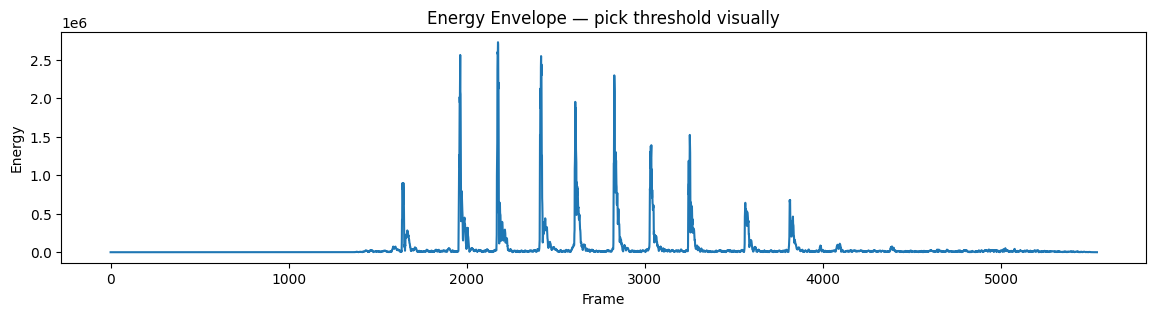

Min:     0.0
Max:     2726030.5
Mean:    57922.77114479653
Median:  10489.224609375
Std:     216017.55435762933


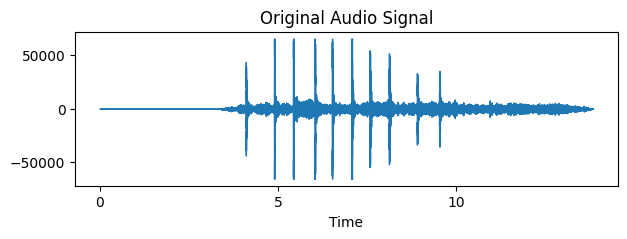

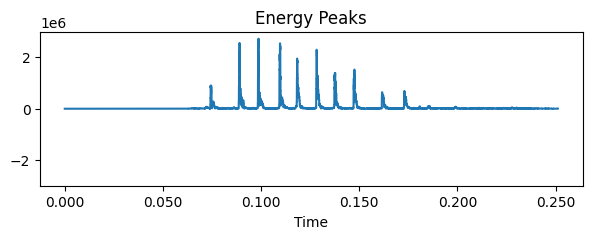

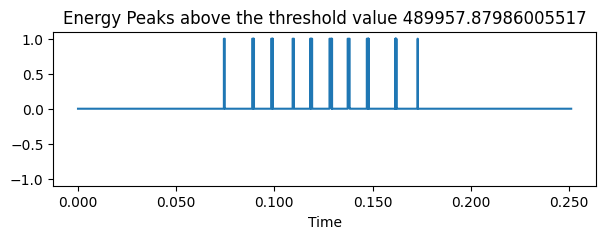

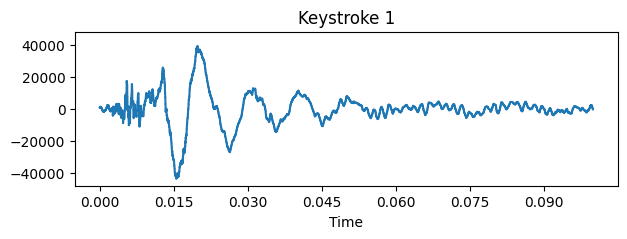

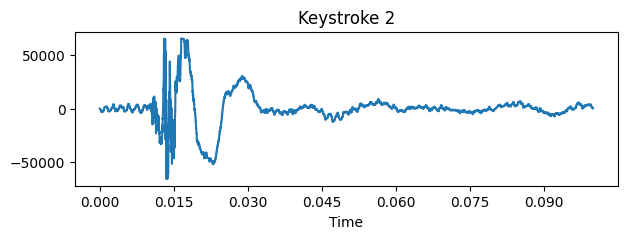

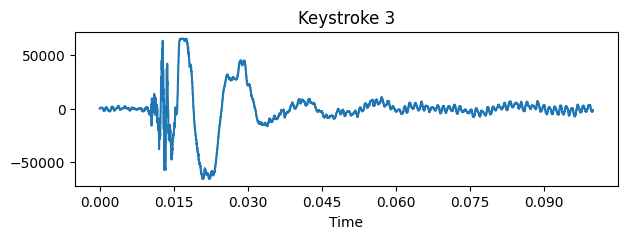

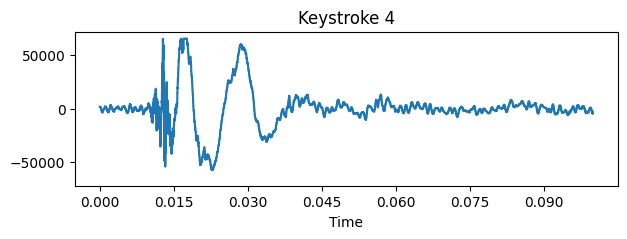

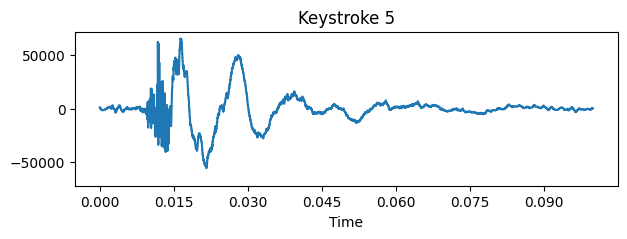

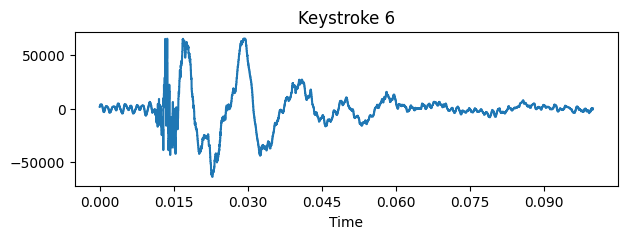

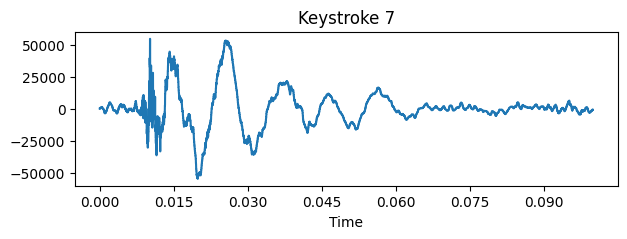

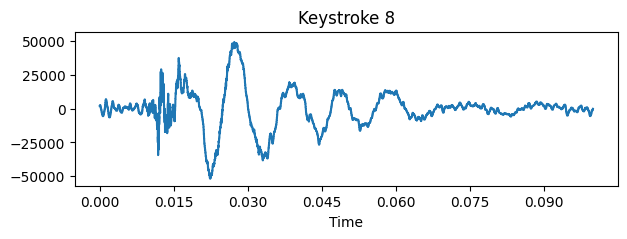

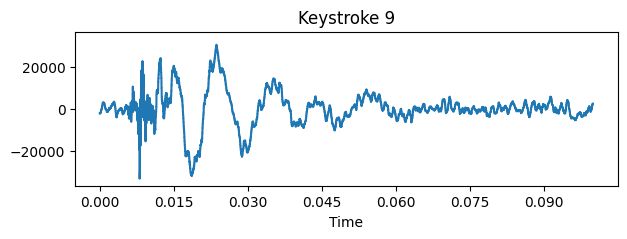

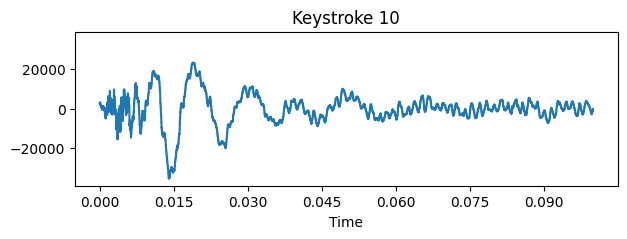

Isolated 10 keystrokes → saved to /Users/davidnguyen/PycharmProjects/MachineLearningProjects/Keyboard -ASCA/InferencePhrase/Zoom(0-9-background-noise)
Combined WAV saved → Zoom(0-9-background-noise)-clean.wav (2.80s)


[tensor([[ 557.2358,  613.9094,  627.8707,  ...,   -3.6407, -132.4806,
          -356.4484]]),
 tensor([[ 182.7087,  -64.8067, -249.9998,  ...,  443.4979,  224.5850,
           242.4996]]),
 tensor([[   73.0179,   290.9386,   506.1483,  ..., -2079.4307, -1780.7340,
          -1384.1750]]),
 tensor([[ 1913.6130,  1884.0341,  1860.0021,  ..., -4368.6177, -3618.6104,
          -3127.3689]]),
 tensor([[1316.5167, 1250.2804, 1145.2615,  ...,  505.2263,  408.4265,
           356.2296]]),
 tensor([[1685.1998, 2077.0400, 2402.2529,  ..., -649.0042,  -86.8855,
           262.6877]]),
 tensor([[  119.5740,    10.2269,    14.7192,  ...,  -849.5494, -1007.7808,
           -964.2638]]),
 tensor([[1972.6539, 2213.2004, 2452.8171,  ..., -401.5748, -208.2485,
           -66.6114]]),
 tensor([[-2206.7314, -2267.0769, -2303.6875,  ...,  2493.9824,  2514.9595,
           2424.1130]]),
 tensor([[2331.1023, 2626.1113, 3126.3142,  ..., -803.6495, -490.6244,
          -142.3090]])]

In [2]:
INFERENCE_AUDIO = "Zoom(0-9-background-noise).wav"
INFERENCE_DIR = f"./{INFERENCE_AUDIO.split('.')[0]}/"



sampleRate, audioData = wavfile.read(INFERENCE_AUDIO)

print(f"Sample rate: {sampleRate} Hz")
print(f"Audio data shape: {audioData.shape}")
print(f"Audio data type: {audioData.dtype}")

"""Convert audio signal to float32 - Reason because stft only accept float32 dtype"""
audioData = audioData.astype(np.float32) / np.iinfo(np.int16).max

"""Convert stereo to mono"""
if audioData.ndim == 2:
    audioData = np.mean(audioData, axis=1)

"""Assume a keystroke sound is 5-20ms long"""
FFTWindowSize = int(sampleRate * 0.02)
scan = FFTWindowSize // 8 # <- Smaller sliding to capture as much keystrokes as possible, tradeoff longer execution and more computing resources exhausted

before = int(sampleRate * 0.02)   # 20ms
after  = int(sampleRate * 0.08)   # 80ms

# Step 1: Plot the energy envelope and visually inspect
fft = librosa.stft(audioData, n_fft=FFTWindowSize, hop_length=scan)
energy = np.abs(np.sum(fft, axis=0)).astype(float)

plt.figure(figsize=(14, 3))
plt.plot(energy)
plt.title("Energy Envelope — pick threshold visually")
plt.ylabel("Energy")
plt.xlabel("Frame")
plt.show()
plt.close()

# Step 2: Check the distribution
print("Min:    ", energy.min())
print("Max:    ", energy.max())
print("Mean:   ", energy.mean())
print("Median: ", np.median(energy))
print("Std:    ", energy.std())

# Step 3: A good starting threshold is usually:
threshold = energy.mean() + 2 * energy.std()


RecordingKeyStrokesIsolator(audioData, sampleRate, FFTWindowSize, scan, before, after, threshold, INFERENCE_DIR , f"{INFERENCE_AUDIO.split('.')[0]}-clean.wav", show=True)

In [3]:
from sklearn.preprocessing import LabelEncoder




ALL_CLASSES = list("abcdefghijklmnopqrstuvwxyz0123456789")  # 36 classes
label_encoder = LabelEncoder()
label_encoder.fit(ALL_CLASSES)

logitLabels = {}
for char in ALL_CLASSES:
    logitLabels[str(label_encoder.transform([char])[0])] = char

print(logitLabels)

{'10': 'a', '11': 'b', '12': 'c', '13': 'd', '14': 'e', '15': 'f', '16': 'g', '17': 'h', '18': 'i', '19': 'j', '20': 'k', '21': 'l', '22': 'm', '23': 'n', '24': 'o', '25': 'p', '26': 'q', '27': 'r', '28': 's', '29': 't', '30': 'u', '31': 'v', '32': 'w', '33': 'x', '34': 'y', '35': 'z', '0': '0', '1': '1', '2': '2', '3': '3', '4': '4', '5': '5', '6': '6', '7': '7', '8': '8', '9': '9'}


### LOADING MODELS

In [4]:
import torch
import torch.nn as nn

class CoAtNet(nn.Module): #Defines a PyTorch neural network class
    """Improved hybrid CNN + Transformer architecture.
 
    Changes vs. original:
      • 3-channel input (mel + delta + delta²) instead of 1-channel
      • Deeper CNN stem: two conv stages (32 → 64 channels) with residual-style
        double convolutions and spatial dropout for regularisation
      • GELU activations (smoother gradient flow than ReLU)
      • Correct reshape: (B,C,H,W) → (B, H*W, C) token layout
      • Linear projection from CNN output dim (64) to transformer d_model (128)
      • Wider transformer: d_model=128, 4 heads, dim_feedforward=256, 3 layers
      • Pre-norm (norm_first=True) for more stable MPS training
      • Configurable dropout so Zoom model can use a higher value
    """

    def __init__(self, num_classes=36, dropout=0.3): #makes the class callable, uses 36 output classes [a-z,0-9] and 30% of neurons dropout to prevent overfitting
        """We only train to recognize keystroke a-z0-9, adding regulatization to reduce overfitting"""
        super(CoAtNet, self).__init__() #calls pyTorch's class contructor

        # Convolutional part
        # Input: (Batch, 3, 128, Tensor)
        # Stage 1: 3 -> 32 channels, halve spatial dims
        # Stage 2: 32 -> 64 channels, halve spatial dims
        
        self.conv_layers = nn.Sequential(
            # Stage 1 - double conv
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), # Takes 3 input channel (grayscale mel spectrogram, delta, and delta2) and output 32 features map, padding to keep spatial dimension the same
            nn.BatchNorm2d(32), # Normalizes each batch to stabilize and speed up training
            nn.GELU(), # Using Gelu instead of ReLu
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Halves spatial dimensions (height and width) by taking the max in each 2×2 region — reduces computation and adds spatial invariance -> (B, 32, H/2, W/2)
            nn.Dropout2d(p=0.1), # Spatial dropout,

            # Stage 2 - double conv with channel expansion
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1), # Takes 32 input channels output from the previous stage
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # -> (B, 32, H/4, W/4)
            nn.Dropout2d(p=0.1)
        )

        # Projecting CNN output dim -> transformer d_model
        CNN_OUT_DIM = 64
        D_MODEL = 128
        self.proj = nn.Linear(CNN_OUT_DIM, D_MODEL)
        

        # Transformer part
        """The transformer uses 4 attention heads and 3 encoder layers and dropout for regularization"""
        encoder_layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=256, dropout=dropout, batch_first=True, norm_first=True)
        """Embedding Dimension must matched the ouput feature vector from the CNN layer, in this case, 64"""
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.dropout = nn.Dropout(p=dropout)

        # Linear classifier
        """Final fully connected layer mapping the 64-dimensional feature vector to num_classes (64) output logits — one score per possible key."""
        self.fc = nn.Linear(D_MODEL, num_classes)

    def forward(self, x):
        """"Input the spectrogram samples in a batch (batch, 3, height, width)"""
        x = self.conv_layers(x)
        """Resulting output of (batch, 64, height/4, width/4)"""

        # Flattening
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1) # Re order to  (Batch, Height, Width, Channel)
        x = x.reshape(B, H * W, C)
        """Reshapes for Transformer input. Transformer expects (sequence_length, batch, features) or (batch, sequence_length, features)"""
        x = self.proj(x)

        # Transformer encoder
        """Passing through the 3 encoder layers"""
        x = self.transformer_encoder(x)
        """Resulting output of (Batch, Height * Width, 128)"""

        """Global max pooling over the sequence dimension — collapses (batch, seq_len, 128) → (batch, 128)"""
        x, _ = torch.max(x, dim=1)

        """Apply dropout before final classification"""
        x = self.dropout(x)

        """Maps (batch, 128) → (batch, 36) — raw logit scores for each class"""
        # Classifier
        x = self.fc(x)
        return x

    def get_num_params(self): #counts and returns the total number of trainable parameter
        """Return the number of trainable parameters"""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


def loadModel(modelPath, device, task):
    if task == "Phone":
        model = CoAtNet(dropout=0.3)
    else:
        model = CoAtNet(dropout=0.4)
    model.load_state_dict(torch.load(modelPath, map_location=device, weights_only=True))
    model = model.to(device)
    model.eval()
    print(f"✓ Model loaded from: {modelPath}")
    print(f"✓ Model on device: {device}")
    print(f"✓ Model in evaluation mode\n")    
    return model
    

In [5]:
models = {
    # "Phone Audio CoATnet Version 3 (80/20)": loadModel("./Models/CoATnetVersion3/80-20-StopAtNoImprovement/PhoneAudioCoATnet.pth", "mps", "Phone"),
    "Zoom Audio CoATnet Version 3 (80/20)": loadModel("./Models/CoATnetVersion3/80-20-StopAtNoImprovement/ZoomAudioCoATnet.pth", "mps", "Zoom"),
    # "Phone Audio CoATnet Version 3 (60/40)": loadModel("./Models/CoATnetVersion3/60-40-StopeAtNoImprovement/PhoneAudioCoATnet.pth", "mps", "Phone"),
    "Zoom Audio CoATnet Version 3 (60/40)": loadModel("./Models/CoATnetVersion3/60-40-StopeAtNoImprovement/ZoomAudioCoATnet.pth", "mps", "Zoom")
    #"Phone Audio CoATnet Version 3 (40/60)": loadModel("./Models/CoATnetVersion3/40-60-StopAtNoImprovement/PhoneAudioCoATnet.pth", "mps", "Phone"),
    #"Zoom Audio CoATnet Version 3 (40/60)": loadModel("./Models/CoATnetVersion3/40-60-StopAtNoImprovement/ZoomAudioCoATnet.pth", "mps", "Zoom")
}

/opt/miniconda3/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


✓ Model loaded from: ./Models/CoATnetVersion3/80-20-StopAtNoImprovement/ZoomAudioCoATnet.pth
✓ Model on device: mps
✓ Model in evaluation mode

✓ Model loaded from: ./Models/CoATnetVersion3/60-40-StopeAtNoImprovement/ZoomAudioCoATnet.pth
✓ Model on device: mps
✓ Model in evaluation mode



### Transforming Keystroke Audio To Spectrogram

In [6]:
LargestMelframes = 0
AllMelFrames = []
AudioSampleRates = []
for dirpath, _, filenames in os.walk(INFERENCE_DIR):
    for filename in sorted(filenames):
        if filename.endswith(".wav"):
            filepath = os.path.join(dirpath, filename)
            print(f"Reading keystroke WAV File at path {filepath}")
            signals, sampleRate = librosa.load(filepath, mono=True)
            mel = librosa.feature.melspectrogram(y=signals, sr=sampleRate, n_fft=2048, hop_length=225)
            melFrames = mel.shape[1]
            AllMelFrames.append(melFrames)
            print(f"Total Audio frames: {len(signals)}")
            print(f"Sample Rate: {sampleRate} Hz")
            print(f"Total Meltrogram time frames: {melFrames}")
            LargestMelframes = max(LargestMelframes, melFrames)
            AudioSampleRates.append(sampleRate)

print(f"Final largest Meltrogram nframes in inference audio: {LargestMelframes}")
MeanAudioSampleRate = sum(AudioSampleRates) // len(AudioSampleRates)
print(f"Mean sample rate across all audios in infrerence audio: {MeanAudioSampleRate}")

Reading keystroke WAV File at path ./Zoom(0-9-background-noise)/1.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./Zoom(0-9-background-noise)/10.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./Zoom(0-9-background-noise)/2.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./Zoom(0-9-background-noise)/3.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./Zoom(0-9-background-noise)/4.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./Zoom(0-9-background-noise)/5.wav
Total Audio frames: 2205
Sample Rate: 22050 Hz
Total Meltrogram time frames: 10
Reading keystroke WAV File at path ./Zoom(0-9-background-noise)/6.wav
Total Audio frames: 2205
Samp

In [7]:
from torchvision.transforms import Compose, ToTensor


"""This transform the audio signal into mel-spectrogram, which will be the input for CoATnet model to processed"""
class ToMelSpectrogram: #class definition (this class converts audio into spectogram images which the model will be able to process)
    """"Augmentation is only APPLIED during training only to prevent overfitting"""
    def __init__(self, targetFrames=99, sampleRates=44100): #takes 3 input parameters; spectogram width will be 99, and the sample rate is set to 44100
        self.targetFrames = targetFrames
        self.sampleRates = sampleRates #audio quality

    def __call__(self, samples): #makes the class callable\
        mel = librosa.feature.melspectrogram(y=samples, sr=self.sampleRates, n_mels=128, n_fft=2048, hop_length=225)
        """Convert power spectrogram to dB scale — better for model training"""
        melDb = librosa.power_to_db(mel, ref=np.max)

        """Capture attach/decay shape of each keystrokes"""
        delta  = librosa.feature.delta(melDb)
        delta2  = librosa.feature.delta(melDb, order=2)
        
        """Fix Melotrogram Length"""
        def fixLength(arr):
            cur = arr.shape[1]
            if cur < self.targetFrames:
                arr = np.pad(arr, ((0, 0), (0, self.targetFrames - cur)), mode='constant', constant_values=arr.min())
            elif cur > self.targetFrames:
                arr = arr[:, :self.targetFrames]
            return arr

        melDb = fixLength(melDb)
        delta = fixLength(delta)
        delta2 = fixLength(delta2)
        

        """Stack into (3, n_mels, T) - analogous to RGB channels"""
        stacked = np.stack([melDb, delta, delta2], axis=0).astype(np.float32)
        return stacked

### Inference

In [8]:
Transform = ToMelSpectrogram(targetFrames=LargestMelframes, sampleRates=MeanAudioSampleRate)
device = 'mps'

for dirpath, _, filenames in os.walk(INFERENCE_DIR):
    for filename in sorted(filenames):
        if filename.endswith(".wav"):
            filepath = os.path.join(dirpath, filename)
            print(f"Transforming WAV File at path {filepath} to Meltrogram\n\n")
            waveform, _ = librosa.load(filepath, mono=True)
            waveform = torch.from_numpy(Transform(waveform)).unsqueeze(0).to(device)
            for model in models:
                print('='*80)
                print(f"{model} - prediction for audio at path {filepath}")
                print('='*80)
                with torch.no_grad():
                    logits = models[model](waveform)
                    probs = torch.softmax(logits, dim=1)
                    prediction = torch.argmax(probs, dim=1).item()
                    confidence = probs[0, prediction].item()
                    top3Probs, top3idx = torch.topk(probs, 5, dim=1)
                    
                print(f"Predicted Keystroke: {logitLabels[str(prediction)]}")
                print(f"Confidence: {confidence:.4f}")
                print(f"Top 5 predictions   :")
                for j in range(5):
                    char  = logitLabels[str(top3idx[0][j].item())]
                    prob  = top3Probs[0][j].item()
                    bar   = '█' * int(prob * 20)
                    print(f"  '{char}' : {prob:.4f}  {bar}")
                print("\n\n")

Transforming WAV File at path ./Zoom(0-9-background-noise)/1.wav to Meltrogram


Zoom Audio CoATnet Version 3 (80/20) - prediction for audio at path ./Zoom(0-9-background-noise)/1.wav
Predicted Keystroke: q
Confidence: 0.3420
Top 5 predictions   :
  'q' : 0.3420  ██████
  'a' : 0.2286  ████
  't' : 0.0709  █
  'w' : 0.0555  █
  '8' : 0.0372  



Zoom Audio CoATnet Version 3 (60/40) - prediction for audio at path ./Zoom(0-9-background-noise)/1.wav
Predicted Keystroke: a
Confidence: 0.4294
Top 5 predictions   :
  'a' : 0.4294  ████████
  'q' : 0.0896  █
  's' : 0.0843  █
  'w' : 0.0510  █
  'z' : 0.0406  



Transforming WAV File at path ./Zoom(0-9-background-noise)/10.wav to Meltrogram


Zoom Audio CoATnet Version 3 (80/20) - prediction for audio at path ./Zoom(0-9-background-noise)/10.wav
Predicted Keystroke: q
Confidence: 0.4372
Top 5 predictions   :
  'q' : 0.4372  ████████
  'a' : 0.3622  ███████
  '8' : 0.0243  
  't' : 0.0235  
  'w' : 0.0171  



Zoom Audio CoATnet Version 3 (60/